In [125]:
import numpy as numpy
import pandas as pd
import seaborn as sns

In [126]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.impute import SimpleImputer,KNNImputer
from sklearn.compose import ColumnTransformer

In [127]:
df=pd.read_csv('titanic_train.csv')

In [128]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [129]:
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
242,243,0,2,"Coleridge, Mr. Reginald Charles",male,29.0,0,0,W./C. 14263,10.5000,NaN,S
866,867,1,2,"Duran y More, Miss. Asuncion",female,27.0,1,0,SC/PARIS 2149,13.8583,NaN,C
275,276,1,1,"Andrews, Miss. Kornelia Theodosia",female,63.0,1,0,13502,77.9583,D7,S
533,534,1,3,"Peter, Mrs. Catherine (Catherine Rizk)",female,NaN,0,2,2668,22.3583,NaN,C
108,109,0,3,"Rekic, Mr. Tido",male,38.0,0,0,349249,7.8958,NaN,S


In [131]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [132]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [133]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [134]:
df.drop(columns=['PassengerId','Name','Ticket','Cabin'],inplace=True)

In [150]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,NaN,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


Aam Zindagi

In [96]:
imputer=SimpleImputer(strategy='mean')
imputer2=SimpleImputer(strategy='most_frequent')
X_embarked=imputer2.fit_transform(df[['Embarked']])
kimputer=KNNImputer(n_neighbors=3)
df['Age']=imputer.fit_transform(df[['Age']])

In [98]:
X_embarked.dtype

dtype('O')

In [100]:
df.isna().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    2
dtype: int64

In [99]:
ohe=OneHotEncoder(sparse_output=False,drop='first')
df_embarked=pd.DataFrame(ohe.fit_transform(X_embarked))
df_sex=pd.DataFrame(ohe.fit_transform(df[['Sex']]))


In [101]:
df['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [102]:
df['Embarked'].value_counts()  

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [104]:
df_embarked.columns=['S','C']
df_sex.columns=['Male']

In [78]:
df_embarked

,S,C,Q
0,0.0,1.0,0.0
1,0.0,0.0,0.0
2,0.0,1.0,0.0
3,0.0,1.0,0.0
4,0.0,1.0,0.0
...,...,...,...
886,0.0,1.0,0.0
887,0.0,1.0,0.0
888,0.0,1.0,0.0
889,0.0,0.0,0.0


In [107]:
df=pd.concat([df,df_embarked,df_sex],axis=1)

In [105]:
df.drop(['Embarked', 'Sex'],axis=1,inplace=True)

In [108]:
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,S,C,Male
0,0,3,22.0,1,0,7.2500,0.0,1.0,1.0
1,1,1,38.0,1,0,71.2833,0.0,0.0,0.0
2,1,3,26.0,0,0,7.9250,0.0,1.0,0.0
3,1,1,35.0,1,0,53.1000,0.0,1.0,0.0
4,0,3,35.0,0,0,8.0500,0.0,1.0,1.0


In [109]:
df.isnull().sum()

Survived    0
Pclass      0
Age         0
SibSp       0
Parch       0
Fare        0
S           0
C           0
Male        0
dtype: int64

C:\Users\umair\AppData\Local\Temp\ipykernel_24272\1382007937.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Age'],hist=False)


<Axes: xlabel='Age', ylabel='Density'>

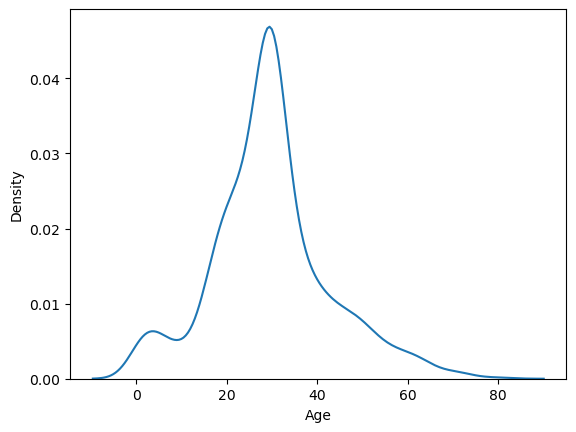

In [116]:
sns.distplot(df['Age'],hist=False)
# sns.distplot(df['S'])

In [117]:
model=LogisticRegression()

In [118]:
X_train, X_test, y_train, y_test = train_test_split(df.drop('Survived',axis=1),df['Survived'],test_size=0.2,random_state=42)

In [119]:
model.fit(X_train,y_train)

c:\Users\umair\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [121]:
prediction=model.predict(X_test)

In [122]:
print("Accuracy:",accuracy_score(y_test,prediction))

Accuracy: 0.7988826815642458


Mentos Zindagi

In [183]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [184]:
trf=ColumnTransformer(transformers=[
    ('embarked',SimpleImputer(strategy='most_frequent'),['Embarked']),
    ('cat',OneHotEncoder(drop='first',sparse_output=False),['Embarked']),
    ('num',SimpleImputer(strategy='mean'),['Age'])
],remainder='passthrough')

In [185]:
pipe=Pipeline(steps=[
    ('transformer',trf),
])

In [193]:
data=pd.DataFrame(pipe.fit_transform(df.drop('Survived',axis=1)))

In [194]:
data

,0,1,2,3,4,5,6,7,8,9
0,S,0.0,1.0,0.0,22.0,3,male,1,0,7.25
1,C,0.0,0.0,0.0,38.0,1,female,1,0,71.2833
2,S,0.0,1.0,0.0,26.0,3,female,0,0,7.925
3,S,0.0,1.0,0.0,35.0,1,female,1,0,53.1
4,S,0.0,1.0,0.0,35.0,3,male,0,0,8.05
...,...,...,...,...,...,...,...,...,...,...
886,S,0.0,1.0,0.0,27.0,2,male,0,0,13.0
887,S,0.0,1.0,0.0,19.0,1,female,0,0,30.0
888,S,0.0,1.0,0.0,29.699118,3,female,1,2,23.45
889,C,0.0,0.0,0.0,26.0,1,male,0,0,30.0


In [195]:
data

,0,1,2,3,4,5,6,7,8,9
0,S,0.0,1.0,0.0,22.0,3,male,1,0,7.25
1,C,0.0,0.0,0.0,38.0,1,female,1,0,71.2833
2,S,0.0,1.0,0.0,26.0,3,female,0,0,7.925
3,S,0.0,1.0,0.0,35.0,1,female,1,0,53.1
4,S,0.0,1.0,0.0,35.0,3,male,0,0,8.05
...,...,...,...,...,...,...,...,...,...,...
886,S,0.0,1.0,0.0,27.0,2,male,0,0,13.0
887,S,0.0,1.0,0.0,19.0,1,female,0,0,30.0
888,S,0.0,1.0,0.0,29.699118,3,female,1,2,23.45
889,C,0.0,0.0,0.0,26.0,1,male,0,0,30.0


In [197]:
data.drop(columns=[0,6],inplace=True)

In [198]:
X=data.drop(columns=[7])

In [199]:
y=df['Survived']
print(y.value_counts())

Survived
0    549
1    342
Name: count, dtype: int64


In [200]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [201]:
model=LogisticRegression()

In [202]:
y_train

331    0
733    0
382    0
704    0
813    0
      ..
106    1
270    0
860    0
435    1
102    0
Name: Survived, Length: 712, dtype: int64

In [203]:
model.fit(X_train,y_train)

c:\Users\umair\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [204]:
prediction=model.predict(X_test)
print(accuracy_score(y_test,prediction))

0.7486033519553073
